# 📘 บทที่ 01 — reflectivity: z, Z, dBZ และความสัมพันธ์ Z–R
### หลักสูตรแลปเรดาร์ตรวจอากาศด้วย Py-ART และ wradlib

**ระดับ:** ขั้นต้น  |  **สิ่งที่ต้องมีก่อน:** รันบทที่ 00 แล้ว (บทนี้ไม่ต้องใช้ไฟล์เรดาร์ เป็นการคำนวณล้วน จึงรันเดี่ยว ๆ ก็ได้)

**วัตถุประสงค์การเรียนรู้**
- เข้าใจความหมายของ reflectivity ทั้งค่าเชิงเส้น `z` และค่าลอการิทึม `dBZ`
- แปลงค่าไป–กลับระหว่าง `z` และ `dBZ` ได้
- เข้าใจสมการความสัมพันธ์ **Z–R** (`z = a·R^b`) และแปลง `dBZ` เป็นอัตราฝน `R`
- เปรียบเทียบสูตร Z–R ที่ใช้บ่อย (Marshall-Palmer, Rosenfeld เขตร้อน, summer convection) และเลือกใช้ให้เหมาะกับภูมิอากาศไทย

---


## 🧠 หลักการเบื้องต้น

เมื่อเรดาร์ยิงคลื่นไมโครเวฟไปกระทบเม็ดฝน พลังงานส่วนหนึ่งสะท้อนกลับ ความเข้มของการสะท้อนกลับสัมพันธ์กับขนาดและจำนวนของเม็ดน้ำในปริมาตรที่ตรวจวัด เรียกปริมาณนี้ว่า **reflectivity factor** สัญลักษณ์ `z` มีหน่วย **mm⁶/m³**

ค่า `z` ครอบคลุมช่วงกว้างมาก (ตั้งแต่ฝนปรอยไปจนถึงพายุลูกเห็บ อาจต่างกันหลายล้านเท่า) จึงนิยมแปลงเป็นสเกลลอการิทึมหน่วย **dBZ**:

$$Z\,[\text{dBZ}] = 10 \cdot \log_{10}(z) \qquad\Longleftrightarrow\qquad z = 10^{\,Z/10}$$

**ความสัมพันธ์ Z–R** — เชื่อม reflectivity กับ **อัตราฝน** `R` (mm/hr) ผ่านสมการยกกำลัง:

$$z = a \cdot R^{\,b} \qquad\Longrightarrow\qquad R = \left(\frac{z}{a}\right)^{1/b}$$

ค่าคงที่ `a`, `b` ขึ้นกับชนิด/ลักษณะของฝน ตัวอย่างที่ใช้บ่อย:

| สูตร | a | b | เหมาะกับ |
|---|---|---|---|
| **Marshall–Palmer** | 200 | 1.6 | ฝนสตราติฟอร์ม/ฝนปรอยถึงปานกลาง |
| **Rosenfeld (tropical)** | 250 | 1.2 | ฝนฟ้าคะนองในเขตร้อน |
| **Summer deep convection** | 300 | 1.4 | เมฆพาความร้อนฤดูร้อนละติจูดกลาง |

> ประเทศไทยอยู่ในเขตร้อน ฝนส่วนใหญ่เป็นแบบพาความร้อน — สูตรของ Rosenfeld จึงมักเหมาะกว่า Marshall–Palmer ซึ่งเราจะเห็นชัดจากกราฟท้ายบท


## ⚙️ ส่วนหัวมาตรฐาน (ติดตั้งไลบรารี + เชื่อม Drive)

บทนี้ใช้เพียง numpy / matplotlib / pandas (มีอยู่แล้วใน Colab) และเชื่อม Drive เพื่อบันทึกผลลัพธ์ลงโฟลเดอร์หลักสูตร


In [1]:
%pip install -q matplotlib numpy pandas

In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── เชื่อม Drive + หา path ผลลัพธ์จาก course_paths (บทนี้ไม่ต้องใช้ข้อมูลเรดาร์) ──
ROOT = '/content/drive/MyDrive/tmd_radar_course'
try:
    from google.colab import drive
    drive.mount('/content/drive')
    sys.path.append(os.path.join(ROOT, '9config'))
    import course_paths as P
    OUT = P.results_dir('lesson01')
except Exception as e:
    OUT = './lesson01_results'; os.makedirs(OUT, exist_ok=True)
    print("หมายเหตุ: ไม่พบ course_paths (ยังไม่ได้รันบท 00) — บทนี้คำนวณล้วน จึงทำงานต่อได้")
print("ผลลัพธ์จะบันทึกที่:", OUT)

# ── สไตล์กราฟระดับตีพิมพ์ (ฟอนต์ใหญ่ อ่านง่าย) ──
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 300, 'font.size': 13,
    'axes.titlesize': 18, 'axes.labelsize': 15,
    'xtick.labelsize': 13, 'ytick.labelsize': 13, 'legend.fontsize': 13,
    'axes.grid': True, 'grid.alpha': 0.3,
})

Mounted at /content/drive
ผลลัพธ์จะบันทึกที่: /content/drive/MyDrive/tmd_radar_course/1results/lesson01


### 🔤 ติดตั้งฟอนต์ไทยสำหรับกราฟ (จำเป็น — มิฉะนั้นข้อความไทยจะแสดงเป็นกล่อง □□□)

ดาวน์โหลดฟอนต์ **Sarabun** (ฟอนต์ราชการไทย เหมาะงานตีพิมพ์) มาลงทะเบียนกับ matplotlib พร้อมตั้งสไตล์กราฟระดับตีพิมพ์ — รันเซลล์นี้ก่อนพลอตทุกครั้ง

In [3]:
# ── ติดตั้ง & ตั้งค่าฟอนต์ไทยให้ matplotlib (ต้องรันก่อนพลอตกราฟที่มีข้อความไทย) ──
import os, glob, subprocess, urllib.request
import matplotlib as mpl, matplotlib.pyplot as plt, matplotlib.font_manager as fm

def setup_thai_font(verbose=True):
    d = '/usr/share/fonts/truetype/sarabun'; os.makedirs(d, exist_ok=True)
    # 1) Sarabun จาก Google Fonts (ฟอนต์ราชการไทย)
    if not glob.glob(d + '/*.ttf'):
        base = 'https://github.com/google/fonts/raw/main/ofl/sarabun/'
        for fn in ('Sarabun-Regular.ttf', 'Sarabun-Bold.ttf'):
            try: urllib.request.urlretrieve(base + fn, os.path.join(d, fn))
            except Exception: pass
    # 2) สำรอง: ฟอนต์ไทย TLWG ผ่าน apt (มีใน Colab เสมอ)
    if not glob.glob(d + '/*.ttf') and not glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        subprocess.run(['apt-get', '-qq', '-y', 'install', 'fonts-thai-tlwg'], capture_output=True)
    # ลงทะเบียนฟอนต์ที่ติดตั้ง
    for fp in glob.glob(d + '/*.ttf') + glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        try: fm.fontManager.addfont(fp)
        except Exception: pass
    avail = {f.name for f in fm.fontManager.ttflist}
    chosen = next((n for n in ('Sarabun','Loma','Garuda','Norasi') if n in avail), None)
    if chosen: mpl.rcParams['font.family'] = chosen
    mpl.rcParams['axes.unicode_minus'] = False
    if verbose:
        print('ฟอนต์ไทยที่ใช้:', chosen or 'ไม่พบ — ลองรันเซลล์นี้อีกครั้งหลังติดตั้ง')
    return chosen

setup_thai_font()
# สไตล์กราฟระดับตีพิมพ์ (ฟอนต์ใหญ่ อ่านง่าย)
plt.rcParams.update({'figure.dpi':120, 'savefig.dpi':300, 'font.size':13,
    'axes.titlesize':16, 'axes.labelsize':14, 'xtick.labelsize':12,
    'ytick.labelsize':12, 'legend.fontsize':13, 'axes.unicode_minus':False})

ฟอนต์ไทยที่ใช้: Sarabun


## 1️⃣ แปลงค่า z → dBZ

ค่า `z` เชิงเส้นครอบคลุมหลายอันดับของขนาด การแปลงเป็น dBZ ช่วยบีบให้อยู่ในช่วงที่อ่านง่าย (โดยทั่วไป −30 ถึง ~70 dBZ)


In [4]:
def Z_to_dBZ(z):
    "แปลง reflectivity เชิงเส้น z (mm^6/m^3) -> dBZ"
    return 10.0 * np.log10(z)

# ตัวอย่างค่า z ที่ห่างกันทีละ 10 เท่า
z = np.array([1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8])
tbl1 = pd.DataFrame({'z (mm^6/m^3)': z, 'dBZ': np.round(Z_to_dBZ(z), 2)})
tbl1

,z (mm^6/m^3),dBZ
0,1.000000e-03,-30.0
1,1.000000e-02,-20.0
2,1.000000e-01,-10.0
3,1.000000e+00,0.0
4,1.000000e+01,10.0
5,1.000000e+02,20.0
6,1.000000e+03,30.0
7,1.000000e+04,40.0
8,1.000000e+05,50.0
9,1.000000e+06,60.0


สังเกตว่า **z เพิ่มขึ้น 10 เท่า → dBZ เพิ่มขึ้น 10 หน่วยเสมอ** นี่คือธรรมชาติของสเกลลอการิทึม ทำให้ค่าที่ต่างกันมหาศาลถูกบีบให้เทียบกันได้ง่าย


## 2️⃣ แปลงค่า dBZ → z (ผกผัน)


In [5]:
def dBZ_to_Z(dBZ):
    "แปลง dBZ -> reflectivity เชิงเส้น z (mm^6/m^3)"
    return 10.0 ** (dBZ / 10.0)

dBZ = np.array([-30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 70])
tbl2 = pd.DataFrame({'dBZ': dBZ, 'z (mm^6/m^3)': dBZ_to_Z(dBZ)})
tbl2

,dBZ,z (mm^6/m^3)
0,-30,1.000000e-03
1,-20,1.000000e-02
2,-10,1.000000e-01
3,0,1.000000e+00
4,10,1.000000e+01
5,20,1.000000e+02
6,30,1.000000e+03
7,40,1.000000e+04
8,50,1.000000e+05
9,60,1.000000e+06


## 3️⃣ ความสัมพันธ์ Z–R: แปลง dBZ → อัตราฝน R

ขั้นตอน: `dBZ → z → R` โดย `R = (z/a)^(1/b)`


In [6]:
def dBZ_to_rainrate(dBZ, a=200.0, b=1.6):
    "แปลง dBZ -> อัตราฝน R (mm/hr) ตามสมการ z = a*R^b"
    z = 10.0 ** (dBZ / 10.0)
    return (z / a) ** (1.0 / b)

# สูตร Z-R ที่ใช้เปรียบเทียบ
ZR = {
    'Marshall-Palmer (200,1.6)': (200.0, 1.6),
    'Rosenfeld tropical (250,1.2)': (250.0, 1.2),
    'Summer convection (300,1.4)': (300.0, 1.4),
}

# ตัวอย่างที่ dBZ = 45
print("ที่ dBZ = 45  →  อัตราฝนตามแต่ละสูตร:")
for name, (a, b) in ZR.items():
    print(f"   {name:32s}: {dBZ_to_rainrate(45, a, b):6.2f} mm/hr")

ที่ dBZ = 45  →  อัตราฝนตามแต่ละสูตร:
   Marshall-Palmer (200,1.6)       :  23.68 mm/hr
   Rosenfeld tropical (250,1.2)    :  56.46 mm/hr
   Summer convection (300,1.4)     :  27.86 mm/hr


## 4️⃣ เปรียบเทียบ 3 สูตร Z–R


In [7]:
# ตารางเทียบที่ค่า dBZ ตัวแทน
dbz_pts = np.array([10, 20, 30, 40, 45, 50, 55, 60])
comp = pd.DataFrame({'dBZ': dbz_pts})
for name, (a, b) in ZR.items():
    comp[name] = np.round(dBZ_to_rainrate(dbz_pts, a, b), 2)
comp

,dBZ,"Marshall-Palmer (200,1.6)","Rosenfeld tropical (250,1.2)","Summer convection (300,1.4)"
0,10,0.15,0.07,0.09
1,20,0.65,0.47,0.46
2,30,2.73,3.17,2.36
3,40,11.53,21.63,12.24
4,45,23.68,56.46,27.86
5,50,48.62,147.36,63.40
6,55,99.85,384.64,144.28
7,60,205.05,1003.96,328.35


บันทึกกราฟที่: /content/drive/MyDrive/tmd_radar_course/1results/lesson01/zr_comparison.png


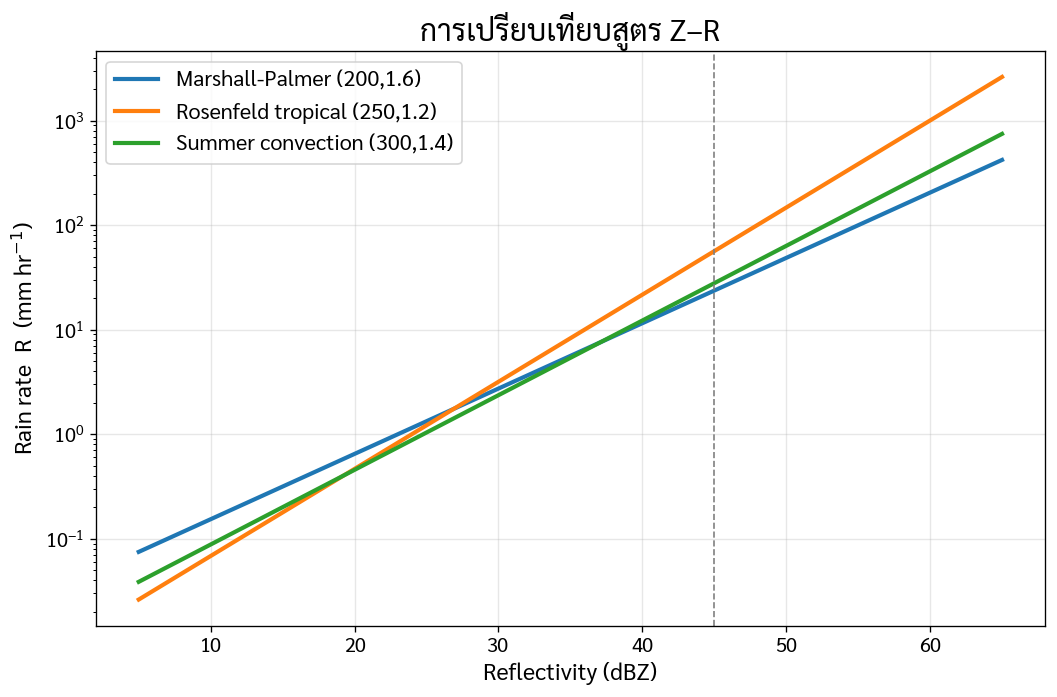

In [8]:
# กราฟ R vs dBZ (แกน y ลอการิทึม เพราะฝนกินหลายอันดับ) — ระดับตีพิมพ์
dbz_axis = np.linspace(5, 65, 300)
fig, ax = plt.subplots(figsize=(9, 6))
for name, (a, b) in ZR.items():
    ax.plot(dbz_axis, dBZ_to_rainrate(dbz_axis, a, b), lw=2.5, label=name)

ax.set_yscale('log')
ax.set_xlabel('Reflectivity (dBZ)')
ax.set_ylabel('Rain rate  R  (mm hr$^{-1}$)')
ax.set_title('การเปรียบเทียบสูตร Z–R', fontsize=18)
ax.axvline(45, color='gray', ls='--', lw=1)
ax.legend(frameon=True)
fig.tight_layout()

save_path = os.path.join(OUT, 'zr_comparison.png')
fig.savefig(save_path, bbox_inches='tight')
print("บันทึกกราฟที่:", save_path)
plt.show()

**อ่านกราฟ:** ที่ dBZ สูง ๆ (ฝนหนัก) สูตร **Rosenfeld (เขตร้อน)** ให้อัตราฝนมากกว่า Marshall–Palmer อย่างเห็นได้ชัด เพราะฝนพาความร้อนในเขตร้อนมีเม็ดใหญ่/ตกหนักกว่าที่ค่า reflectivity เท่ากัน หากใช้ Marshall–Palmer กับฝนเขตร้อนจึงมัก**ประเมินฝนต่ำกว่าจริง** — ประเด็นนี้จะกลับมาสำคัญอีกครั้งในบทที่ 08 (QPE) และบทที่ 12 (zonal statistics รายลุ่มน้ำ)


## 📝 แบบฝึกหัด

1. เพิ่มสูตร Z–R ของคุณเอง (เลือก a, b) ลงใน `ZR` แล้วรันกราฟใหม่ — เส้นขยับอย่างไรเมื่อเพิ่ม a? เมื่อเพิ่ม b?
2. ที่ dBZ = 45 แต่ละสูตรให้ฝนกี่ mm/hr และต่างกันกี่เปอร์เซ็นต์เมื่อเทียบกับ Marshall–Palmer?
3. ค่าฝน 50 mm/hr ตรงกับ dBZ เท่าใดในแต่ละสูตร (แปลงย้อนกลับ)


In [9]:
# แบบฝึกหัดข้อ 2 (เติมให้สมบูรณ์)
base = dBZ_to_rainrate(45, *ZR['Marshall-Palmer (200,1.6)'])
print(f"ฐาน Marshall-Palmer ที่ 45 dBZ = {base:.2f} mm/hr\n")
for name, (a, b) in ZR.items():
    r = dBZ_to_rainrate(45, a, b)
    diff = (r - base) / base * 100
    print(f"   {name:32s}: {r:6.2f} mm/hr  ({diff:+.1f}% เทียบ MP)")

# TODO (นิสิต): ทำข้อ 1 และ 3 ต่อในเซลล์นี้หรือเซลล์ใหม่


ฐาน Marshall-Palmer ที่ 45 dBZ = 23.68 mm/hr

   Marshall-Palmer (200,1.6)       :  23.68 mm/hr  (+0.0% เทียบ MP)
   Rosenfeld tropical (250,1.2)    :  56.46 mm/hr  (+138.4% เทียบ MP)
   Summer convection (300,1.4)     :  27.86 mm/hr  (+17.6% เทียบ MP)


---
## 🎯 สรุป

- `dBZ = 10·log₁₀(z)` และผกผัน `z = 10^(dBZ/10)`
- แปลงฝน: `R = (z/a)^(1/b)` — ค่าคงที่ `a, b` สะท้อนชนิดของฝน
- ฝนเขตร้อนของไทยมักเหมาะกับสูตร Rosenfeld มากกว่า Marshall–Palmer

**บทถัดไป — บทที่ 02:** เปิดไฟล์เรดาร์พิษณุโลกจริงด้วย Py-ART สำรวจ Radar object และพลอต PPI เปรียบเทียบมุมยก
